<a href="https://colab.research.google.com/github/niruinso/Course_Work/blob/develop/src/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)

## Итак, мы обучили модели. Давайте рассмотрим на результаты. В качестве отбора будем использовать меру R-Squared. R² отвечает на вопрос: "Насколько хорошо модель объясняет то, что происходит с целевой переменной?". Формула выглядит следующим образом:
## R² = 1 - (Остаточная дисперсия) / (Общая дисперсия)
## R² = 1 - sum(y_true - y_pred)² / sum(y_true - y_mean)²
## Чем выше коэффициент, тем лучше модель видит паттерн на предсказание целевой переменной (значения от 0 до 1)

In [2]:
linear_res = pd.read_csv("data/result_linear.csv")
svm_res = pd.read_csv("data/results_svm.csv")
tree_knn_res = pd.read_csv("data/results_tree_knn.csv")
ensembles_res = pd.read_csv("data/results_ensembles.csv")

In [3]:
linear_res

,Unnamed: 0,model,params,MAE,RMSE,R2
0,0,Poly Linear Regression,"{'memory': None, 'steps': [('poly', Polynomial...",0.506658,2.269837,0.674013
1,1,Ridge,"{'alpha': 0, 'copy_X': True, 'fit_intercept': ...",0.506636,2.269850,0.674010
2,2,Lasso,"{'alpha': 0.001, 'copy_X': True, 'fit_intercep...",0.506731,2.269761,0.674035
3,3,ElasticNet,"{'alpha': 0.001, 'copy_X': True, 'fit_intercep...",0.506833,2.269814,0.674020


## Lasso тут показывает себя получше (0.674035)

In [5]:
svm_res

,Unnamed: 0,model,params,MAE,RMSE,R2
0,0,SVR RBF kernel,"{'C': 50, 'cache_size': 200, 'coef0': 0.0, 'de...",0.469776,2.272834,0.673152
1,1,SVR Linear Kernel,"{'C': 0.5, 'cache_size': 200, 'coef0': 0.0, 'd...",0.469638,2.272748,0.673177
2,2,SVR Sigmoid Kernel,"{'C': 50, 'cache_size': 200, 'coef0': 0.5, 'de...",0.601261,2.319489,0.659596


## SVR Linear Kernel тут показывает себя получше (0.673177)

In [7]:
tree_knn_res

,Unnamed: 0,model,params,MAE,RMSE,R2
0,0,KNN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",1.800630,3.003335,0.429286
1,1,DesicionTree,"{'ccp_alpha': 0.0, 'criterion': 'absolute_erro...",1.479314,2.798118,0.504615


## DesicionTree тут показывает себя получше (0.504615)

In [9]:
ensembles_res

,Unnamed: 0,model,params,MAE,RMSE,R2
0,0,VotingRegressor,"{'estimators': [('svr_rbf', SVR(C=50, epsilon=...",0.628660,2.310564,0.662210
1,1,BaggingRegressor,"{'bootstrap': True, 'bootstrap_features': Fals...",1.145797,2.519624,0.598318
2,2,RandomForestRegressor,"{'bootstrap': True, 'ccp_alpha': np.float64(0....",1.273089,2.596215,0.573527
3,3,BoostingRegressor,"{'alpha': np.float64(0.4507792984144696), 'ccp...",0.599892,2.301610,0.664823
4,4,StackingRegressor,"{'cv': 5, 'estimators': [('svr_rbf', SVR(C=50,...",0.554674,2.284959,0.669655


## StackingRegressor тут показывает себя получше (0.669655)

## И все же среди всех моделей именно Lasso показало себя лучше. Давайте чуть рассмотрим эту модель и сохраним ее

In [47]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(**eval(linear_res.iloc[2]["params"]))

In [49]:
train_df = pd.read_csv("data/Train.csv")
valid_df = pd.read_csv("data/Valid.csv")
test_df = pd.read_csv("data/Test.csv")

X_train = train_df.drop('Exam_Score', axis=1)
X_valid = valid_df.drop('Exam_Score', axis=1)
X_test = test_df.drop('Exam_Score', axis=1)

y_train = train_df['Exam_Score']
y_valid= valid_df['Exam_Score']
y_test= test_df['Exam_Score']

## Рассмотрим на коэффициенты при признаках для разных значений регуляризации

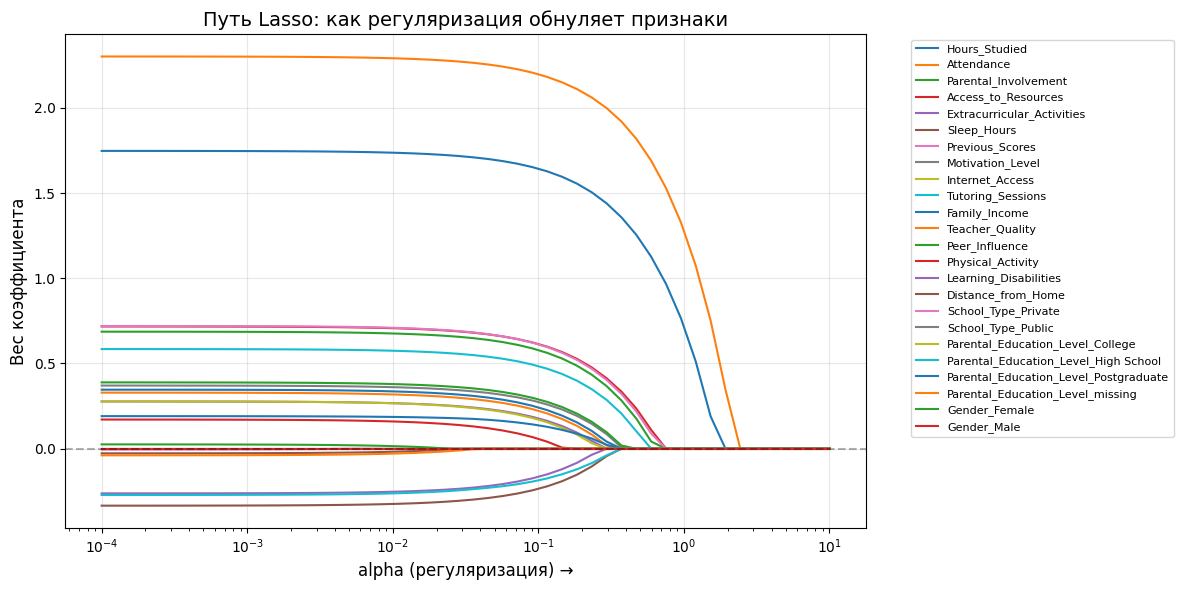

In [50]:
alphas = np.logspace(-4, 1, 50)
coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)
feature_names = X_train.columns
coefs = np.array(coefs)

plt.figure(figsize=(12, 6))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=f'{feature_names[i]}', linewidth=1.5)

plt.xscale('log')
plt.xlabel('alpha (регуляризация) →', fontsize=12)
plt.ylabel('Вес коэффициента', fontsize=12)
plt.title('Путь Lasso: как регуляризация обнуляет признаки', fontsize=14)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Посмотрим, как Лассо определила коэффициенты в нашем случае

In [55]:
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.001, selection='random', tol=0.001)

In [56]:
importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': lasso_model.coef_,
    'Важность': np.abs(lasso_model.coef_)
}).sort_values('Важность', ascending=False)

In [57]:
importance_df

,Признак,Коэффициент,Важность
1,Attendance,2.300969,2.300969
0,Hours_Studied,1.746723,1.746723
6,Previous_Scores,0.719075,0.719075
3,Access_to_Resources,0.716397,0.716397
2,Parental_Involvement,0.685692,0.685692
9,Tutoring_Sessions,0.583767,0.583767
12,Peer_Influence,0.388255,0.388255
7,Motivation_Level,0.369651,0.369651
10,Family_Income,0.345446,0.345446
20,Parental_Education_Level_Postgraduate,0.335273,0.335273


## Под конец - давайте сохраним нашу модель. Да, она простая, но все же)

In [63]:
import joblib

joblib.dump(lasso_model, 'model/best_model.pkl')

['model/best_model.pkl']

## Вот и все.